In [2]:
from dataImporter import *
from experiment import *
from utilityFunctions import *
from tsFeatures import *
from afterAnalysis import *
from visualization import *

import time
from itertools import combinations
import heapq
import re

In [153]:
results

,country_selection,z,running_time,quals,max_qual,avg_quality,quality_measure_counter,covs,max_cov,avg_covs,running_time_normalized
0,Netherlands,2,13.458526,"[7.940278554272425, 8.1408178386682, 8.0129206...",12.196873,9.703808,3013,"[0.023474178403755867, 0.014084507042253521, 0...",0.032864,0.019249,0.168139
1,Netherlands,3,5.249989,"[7.776018910772906, 7.940278554272425, 8.01292...",12.196873,9.356720,1449,"[0.023474178403755867, 0.023474178403755867, 0...",0.032864,0.020188,0.020529
2,Netherlands,4,4.108359,"[6.026296792394931, 6.045378867174053, 6.42029...",12.196873,8.108426,745,"[0.018779342723004695, 0.028169014084507043, 0...",0.032864,0.023474,0.000000
3,Netherlands,5,4.222753,"[5.82706038055552, 5.938760291599279, 5.999361...",12.196873,7.756153,461,"[0.03286384976525822, 0.04225352112676056, 0.0...",0.042254,0.028638,0.002057
4,Netherlands,6,6.794873,"[3.828779355120612, 3.840629890058855, 4.80102...",8.012921,5.414866,351,"[0.03286384976525822, 0.04225352112676056, 0.0...",0.042254,0.034742,0.048310
5,Netherlands,7,15.766163,"[3.777335283820896, 3.840629890058855, 3.82877...",8.012921,5.409147,286,"[0.03755868544600939, 0.04225352112676056, 0.0...",0.042254,0.036150,0.209636
6,Netherlands,8,59.718202,"[2.369965072178393, 2.489998258663008, 4.80102...",5.938760,3.900552,92,"[0.09389671361502347, 0.06103286384976526, 0.0...",0.093897,0.050235,1.000000
7,France,2,20.361308,"[2.6753836492993712, 2.738048072789875, 2.7135...",4.637865,3.085651,1763,"[0.011025358324145534, 0.011025358324145534, 0...",0.015436,0.012459,0.078365
8,France,3,9.104666,"[2.6753836492993712, 2.7702920022206454, 2.713...",4.637865,3.085651,975,"[0.011025358324145534, 0.013230429988974642, 0...",0.015436,0.012459,0.017682
9,France,4,5.824607,"[2.6753836492993712, 2.7135740449352896, 2.738...",4.637865,3.085651,726,"[0.011025358324145534, 0.015435501653803748, 0...",0.015436,0.012459,0.000000


In [167]:
pivot_table = pd.pivot_table(results, values='running_time', index='z', columns='country_selection')
pivot_table = pivot_table.round(1)
# Display the pivot table
print(pivot_table)

country_selection  France  Germany  Netherlands  large_economies
z                                                               
2                    20.4     27.0         13.5            224.9
3                     9.1     11.6          5.2            172.8
4                     5.8      8.6          4.1            158.5
5                     6.6      7.4          4.2            161.1
6                     9.1     14.4          6.8            232.0
7                    37.0     45.8         15.8            659.0
8                   191.3    244.5         59.7           3476.4


In [3]:
results = pd.read_pickle("C:/Users/bengelen003/Downloads/results_hierarchical_z_testing.pkl")

In [4]:
results

,country_selection,z,running_time,quals,max_qual,avg_quality,quality_measure_counter,covs,max_cov,avg_covs
0,[Netherlands],2,13.458526,"[7.940278554272425, 8.1408178386682, 8.0129206...",12.196873,9.703808,3013,"[0.023474178403755867, 0.014084507042253521, 0...",0.032864,0.019249
1,[Netherlands],3,5.249989,"[7.776018910772906, 7.940278554272425, 8.01292...",12.196873,9.356720,1449,"[0.023474178403755867, 0.023474178403755867, 0...",0.032864,0.020188
2,[Netherlands],4,4.108359,"[6.026296792394931, 6.045378867174053, 6.42029...",12.196873,8.108426,745,"[0.018779342723004695, 0.028169014084507043, 0...",0.032864,0.023474
3,[Netherlands],5,4.222753,"[5.82706038055552, 5.938760291599279, 5.999361...",12.196873,7.756153,461,"[0.03286384976525822, 0.04225352112676056, 0.0...",0.042254,0.028638
4,[Netherlands],6,6.794873,"[3.828779355120612, 3.840629890058855, 4.80102...",8.012921,5.414866,351,"[0.03286384976525822, 0.04225352112676056, 0.0...",0.042254,0.034742
5,[Netherlands],7,15.766163,"[3.777335283820896, 3.840629890058855, 3.82877...",8.012921,5.409147,286,"[0.03755868544600939, 0.04225352112676056, 0.0...",0.042254,0.036150
6,[Netherlands],8,59.718202,"[2.369965072178393, 2.489998258663008, 4.80102...",5.938760,3.900552,92,"[0.09389671361502347, 0.06103286384976526, 0.0...",0.093897,0.050235
7,[France],2,20.361308,"[2.6753836492993712, 2.738048072789875, 2.7135...",4.637865,3.085651,1763,"[0.011025358324145534, 0.011025358324145534, 0...",0.015436,0.012459
8,[France],3,9.104666,"[2.6753836492993712, 2.7702920022206454, 2.713...",4.637865,3.085651,975,"[0.011025358324145534, 0.013230429988974642, 0...",0.015436,0.012459
9,[France],4,5.824607,"[2.6753836492993712, 2.7135740449352896, 2.738...",4.637865,3.085651,726,"[0.011025358324145534, 0.015435501653803748, 0...",0.015436,0.012459


In [148]:
for i in range(len(results)):
    if isinstance(results.loc[i,'country_selection'], list):
        results.loc[i,'country_selection'] = results.loc[i,'country_selection'][0]

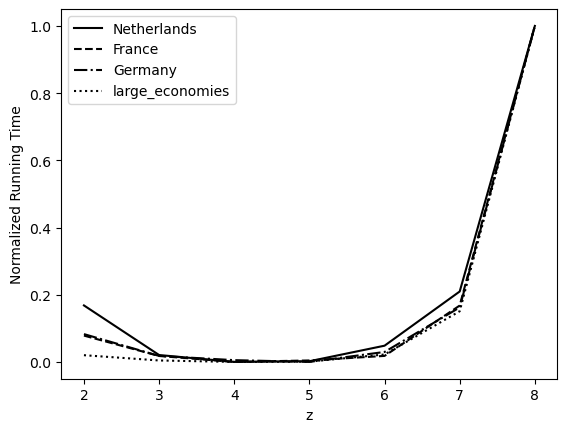

In [158]:
import matplotlib.pyplot as plt
import ast
from sklearn import preprocessing

# Assuming you have a DataFrame named 'results'
# Replace 'results' with the actual name of your DataFrame

# Function to normalize a column using min-max normalization
def normalize_column(column):
    min_max_scaler = preprocessing.MinMaxScaler()
    column_normalized = min_max_scaler.fit_transform(column.values.reshape(-1, 1))
    return column_normalized.flatten()

# Apply min-max normalization to 'running_time' column per 'country_selection'
results['running_time_normalized'] = results.groupby('country_selection')['running_time'].transform(normalize_column)

fig, ax = plt.subplots()

# Define line styles for different countries
line_styles = ['-', '--', '-.', ':']

# Iterate over unique values in 'country_selection' column
for i, country in enumerate(results['country_selection'].unique()):
    # Filter the DataFrame for the current country
    country_df = results[results['country_selection'] == country]
    
    # Plot the normalized data for the current country with a different line style
    ax.plot(country_df['z'], country_df['running_time_normalized'], label=country , color='black',  linestyle=line_styles[i % len(line_styles)])

# Add labels and title to the plot
ax.set_xlabel('z')
ax.set_ylabel('Normalized Running Time')
#ax.set_title('Normalized Running Time vs. z for different country selections')

# Add a legend to differentiate between country selections
ax.legend()

# Save the figure as SVG
plt.savefig('runningtimeVSzscore.svg', format='svg')

# Show the plot
plt.show()


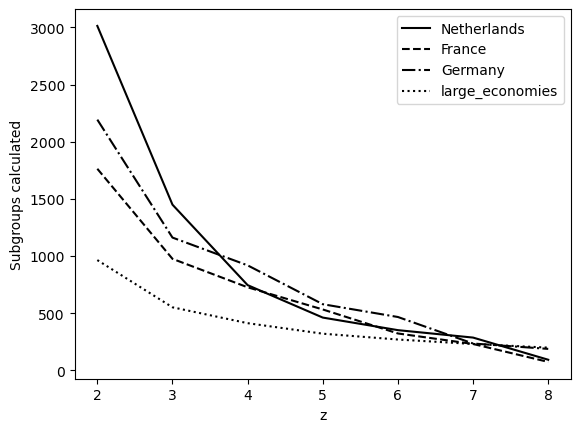

In [159]:
import matplotlib.pyplot as plt
import ast
from sklearn import preprocessing

# Assuming you have a DataFrame named 'results'
# Replace 'results' with the actual name of your DataFrame

# Function to normalize a column using min-max normalization
def normalize_column(column):
    min_max_scaler = preprocessing.MinMaxScaler()
    column_normalized = min_max_scaler.fit_transform(column.values.reshape(-1, 1))
    return column_normalized.flatten()

# Apply min-max normalization to 'running_time' column per 'country_selection'

#results['quality_measure_counter_normalized'] = results.groupby('country_selection')['quality_measure_counter'].transform(normalize_column)

fig, ax = plt.subplots()

# Define line styles for different countries
line_styles = ['-', '--', '-.', ':']

# Iterate over unique values in 'country_selection' column
for i, country in enumerate(results['country_selection'].unique()):
    # Filter the DataFrame for the current country
    country_df = results[results['country_selection'] == country]
    
    # Plot the normalized data for the current country with a different line style
    ax.plot(country_df['z'], country_df['quality_measure_counter'], label=country , color='black',  linestyle=line_styles[i % len(line_styles)])

# Add labels and title to the plot
ax.set_xlabel('z')
ax.set_ylabel('Subgroups calculated')
#ax.set_title('Average Quality Measure vs. z for different country selections')

# Add a legend to differentiate between country selections
ax.legend()

# Save the figure as SVG
plt.savefig('nrqualVSzscore.svg', format='svg')

# Show the plot
plt.show()


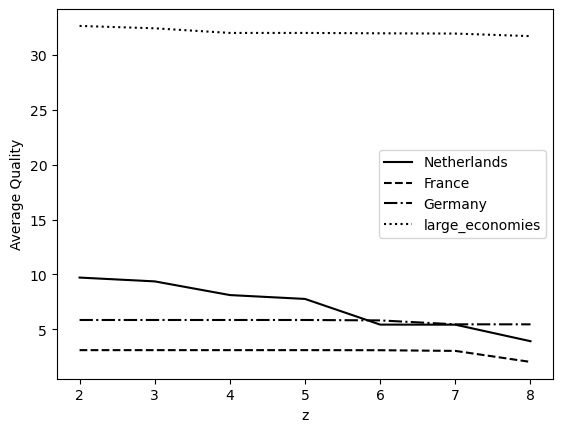

In [161]:
import matplotlib.pyplot as plt
import ast
from sklearn import preprocessing

# Assuming you have a DataFrame named 'results'
# Replace 'results' with the actual name of your DataFrame

# Function to normalize a column using min-max normalization
def normalize_column(column):
    min_max_scaler = preprocessing.MinMaxScaler()
    column_normalized = min_max_scaler.fit_transform(column.values.reshape(-1, 1))
    return column_normalized.flatten()

# Apply min-max normalization to 'running_time' column per 'country_selection'

#results['quality_measure_counter_normalized'] = results.groupby('country_selection')['quality_measure_counter'].transform(normalize_column)

fig, ax = plt.subplots()

# Define line styles for different countries
line_styles = ['-', '--', '-.', ':']

# Iterate over unique values in 'country_selection' column
for i, country in enumerate(results['country_selection'].unique()):
    # Filter the DataFrame for the current country
    country_df = results[results['country_selection'] == country]
    
    # Plot the normalized data for the current country with a different line style
    ax.plot(country_df['z'], country_df['avg_quality'], label=country , color='black',  linestyle=line_styles[i % len(line_styles)])

# Add labels and title to the plot
ax.set_xlabel('z')
ax.set_ylabel('Average Quality')
#ax.set_title('Average Quality Measure vs. z for different country selections')

# Add a legend to differentiate between country selections
ax.legend()

# Save the figure as SVG
plt.savefig('avgqualVSzscore.svg', format='svg')

# Show the plot
plt.show()


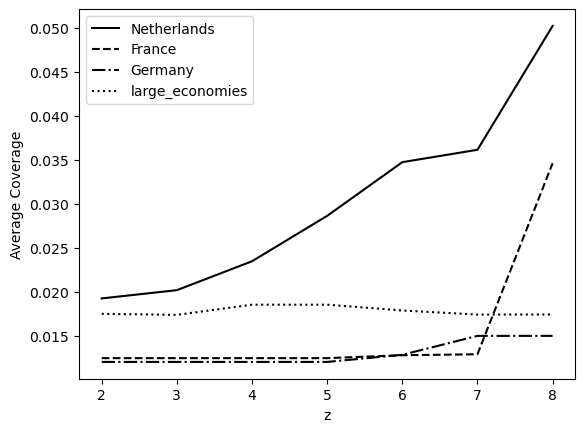

In [162]:
import matplotlib.pyplot as plt
import ast
from sklearn import preprocessing

# Assuming you have a DataFrame named 'results'
# Replace 'results' with the actual name of your DataFrame

# Function to normalize a column using min-max normalization
def normalize_column(column):
    min_max_scaler = preprocessing.MinMaxScaler()
    column_normalized = min_max_scaler.fit_transform(column.values.reshape(-1, 1))
    return column_normalized.flatten()

# Apply min-max normalization to 'running_time' column per 'country_selection'

#results['quality_measure_counter_normalized'] = results.groupby('country_selection')['quality_measure_counter'].transform(normalize_column)

fig, ax = plt.subplots()

# Define line styles for different countries
line_styles = ['-', '--', '-.', ':']

# Iterate over unique values in 'country_selection' column
for i, country in enumerate(results['country_selection'].unique()):
    # Filter the DataFrame for the current country
    country_df = results[results['country_selection'] == country]
    
    # Plot the normalized data for the current country with a different line style
    ax.plot(country_df['z'], country_df['avg_covs'], label=country , color='black',  linestyle=line_styles[i % len(line_styles)])

# Add labels and title to the plot
ax.set_xlabel('z')
ax.set_ylabel('Average Coverage')
#ax.set_title('Average Quality Measure vs. z for different country selections')

# Add a legend to differentiate between country selections
ax.legend()

# Save the figure as SVG
plt.savefig('avgcovVSzscore.svg', format='svg')

# Show the plot
plt.show()


In [67]:
df_original, cat, num, features = getData("Stock5YSmall",countries=['Netherlands'],attributes='expertBased')
df = df_original.copy()

In [68]:
df_test = df
df_test = df_test.reset_index(drop=True)

In [69]:
exp = Experiment("Observation cluster based - ED", df_test, features, w_var=50, d_var=3, q_var=50,
                  min_coverage = 0.001, normalization_var=percent_change_norm, min_coverage_abs = 3) # normalization_var=percentual_differences,
exp.prepare(distance_measure_matrix=euclidean_distance_slopes) # euclidean_distance_time_points, euclidean_distance_slopes, euclidean_distance_concav, polygonal_distance 
euclidean_slope_distance_matrix = exp.distance_matrix
pickle_title = './euclidean_slope_distance_matrix_NL.pkl'
np.save(pickle_title, euclidean_slope_distance_matrix)

In [70]:
#euclidean_slope_distance_matrix = np.load('euclidean_slope_distance_matrix.npy')

In [71]:
exp = Experiment("Observation cluster based - ED", df_test, features, w_var=50, d_var=3, q_var=50,
                  min_coverage = 0.001, normalization_var=percent_change_norm, min_coverage_abs = 3) # normalization_var=percentual_differences,
exp.prepare()

exp.df = exp.df.reset_index(drop=True)

In [100]:
class botumUpSearch:
    
    def __init__(self,df,distance_matrix,number_of_row_pairs,depth,q,nr_chunks=5,min_coverage_perc=0.01,min_coverage_abs=3):
    
        self.matrix = distance_matrix
        self.x = number_of_row_pairs
        self.d = depth
        self.df = df.copy()
        self.df_org = df.copy()
        self.q = q
        self.min_coverage_perc = min_coverage_perc
        self.min_coverage_abs = min_coverage_abs
        self.nr_chunks = nr_chunks
        
        # steps to partition numerical columns into bins
        for col in self.df.columns:
            if (self.df[col].dtype == 'float64') or (self.df[col].dtype == 'float32') or (self.df[col].dtype == 'int64'):
                dat = np.sort(self.df[col])
                dat = dat[np.logical_not(np.isnan(dat))]
                for i in range(1, self.nr_chunks+1):
                    # determine the number of chunks you want to divide your data in
                    x = np.percentile(dat, (i-1)*100/self.nr_chunks)  #
                    y = np.percentile(dat, (i)*100/self.nr_chunks)
                    candidate = "{} <= {} <= {}".format(x ,col, y)
                    self.df[col] = self.df[col].apply(lambda val: candidate if (not isinstance(val, str) and x <= val <= y) else val)
            
            
    def find_min_indices(matrix, x):
        """
        Finds the x smallest distances and returns tuples of the indexes i and j.
        
        matrix = distance matrix
        x = number of pairs we want to find
        """
        
        min_heap = []
        n = len(matrix)

        for i in range(n):
            for j in range(i+1, n):
                if len(min_heap) < x:
                    heapq.heappush(min_heap, (-matrix[i][j], (i, j)))
                else:
                    if matrix[i][j] < -min_heap[0][0]:
                        heapq.heappop(min_heap)
                        heapq.heappush(min_heap, (-matrix[i][j], (i, j)))

        return [idx for val, idx in min_heap]


    def get_common_attributes(rows, d_len):
        """
        Finds the attribute value combinations that are similar in all rows.

        rows = list of rows of a dataframe
        d_len = description length
        """

        common_attributes = []
        attribute_combinations = combinations(rows[0].items(), d_len)

        for combination in attribute_combinations:
            attributes = [f"{attribute} == '{value}'" for attribute, value in combination]
            if all(all(row.get(attribute) == value for attribute, value in combination) for row in rows[1:]):
                common_attributes.append(attributes)
                
        # print("common_attributes = ", common_attributes)

        return common_attributes


    
    def get_unique_lists(list_of_lists):
        """
        Filters redundant descriptions, when they are exactly the same or in a different order.
        """
        
        unique_lists = [list(x) for x in set(tuple(set(sublist)) for sublist in list_of_lists)]
        return unique_lists
    
    def generate_new_tuples(tuples_list, matrix):
        z = len(tuples_list[0])  # Size of the tuples in the original list
        new_tuples_list = []

        for t in tuples_list:
            new_tuples = []

            for index in t:
                row = index
                new_tuple = list(t)  # Create a new tuple based on the existing one

                # Find the minimum value in the row that satisfies the conditions
                min_val = float('inf')
                min_index = None
                for i, val in enumerate(matrix[row]):
                    if val < min_val and i != row and i not in t:
                        min_val = val
                        min_index = i

                new_tuple.append(min_index)  # Add the new index to the tuple
                new_tuples.append(tuple(new_tuple))  # Convert the list back to a tuple and add it to the new list

            new_tuples_list.extend(new_tuples)

        return new_tuples_list   

    
    def findQuality(self, quality_measure = cluster_based_quality_measure, z=3,comparison_type = "complement" ,size_corr = no_size_corr):
        
        self.running_time = time.time()
        self.quality_measure = quality_measure
        self.size_corr = size_corr
        self.quality_measure_counter = 0
        self.comparison_type = comparison_type
        self.z = z
        z=z-2
        
        
        min_heap = []
        len_df = len(self.df)
        
        promising_combinations = botumUpSearch.find_min_indices(self.matrix, self.x)
        print('promising_combinations_start step= ',len(promising_combinations))
        
        promising_combinations_larger_size = promising_combinations
        if z>0:
            for i in range(z):
                promising_combinations_larger_size = botumUpSearch.generate_new_tuples(promising_combinations_larger_size, self.matrix)
             
        print('promising_combinations_mid step= ',len(promising_combinations_larger_size))   
        promising_combinations_larger_size_unique = [tuple(s) for s in {frozenset(t) for t in promising_combinations_larger_size}]
        promising_combinations = promising_combinations_larger_size_unique
        
        print('promising_combinations_large= ',len(promising_combinations))
        
        

        #TODO in line below it only works when target attribute is the last attribute
        
        candidate_descriptions = [botumUpSearch.get_common_attributes([self.df.iloc[i][:-1] for i in index_tuple],d) for index_tuple in promising_combinations for d in range(1,self.d+1)]
        print('descriptions',len(candidate_descriptions))

        # unique_candidate_descriptions gives the unique potential candidate descriptions
        unique_candidate_descriptions = botumUpSearch.get_unique_lists([item for sublist in candidate_descriptions for item in sublist])
        
        print('unique descriptions',len(unique_candidate_descriptions))

        for desc in unique_candidate_descriptions:
            ind = self.df.query(as_string(desc))
            
            #checks if subgroups comply with size constrains
            if satisfies_all(desc, ind, len_df, self.min_coverage_perc, self.min_coverage_abs):
                
                quality, coverage = eval_quality(ind, self.df, 'target', self.quality_measure, comparison_type,distance_matrix=self.matrix,correct_for_size=size_corr)
                self.quality_measure_counter += 1
                
                if len(min_heap) < self.q:
                    heapq.heappush(min_heap, (quality, desc, coverage))
                    #heapq.heapify(min_heap)
                else:
                    
                    if -quality < -heapq.nsmallest(1, min_heap)[0][0]:

                        equal_quals = [i for i, x in enumerate(min_heap) if x[0] == quality]
                        
                        # checks if set of records isn't already present as a result of a different description
                        if len(equal_quals)>0:
                            for i in equal_quals:
                                comp = self.df.query(as_string(min_heap[i][1]))
                                if np.array_equal(comp.index, ind.index):
                                    pass
                                else:
                                    heapq.heappushpop(min_heap, (quality, desc, coverage))
                        else:
                            heapq.heappushpop(min_heap, (quality, desc, coverage))

        
        self.running_time = time.time() - self.running_time
        
        self.result = sorted(min_heap, key=lambda x: x[0], reverse=True)
        
        
        #part that changes the numerical propositions back into a evaluatable thing instead of a string
        data = self.result
        for i, (value1, sublist, value2) in enumerate(data):
            for j, string in enumerate(sublist):
                
                if any(op in string for op in ['<', '<=', '>', '>=']):
                    # Extract the nested string without the outer quotes
                    try:
                        nested_string = string.split("'")[1]
                     # Replace the string with the extracted nested string
                        sublist[j] = nested_string
                    except:
                        pass
             # Update the modified sublist in the data
            data[i] = ( value1, sublist,value2)
            
        
        self.result = data
        self.quals = [i[0] for i in min_heap]
        self.covs = [i[2] for i in min_heap]
        self.avg_quality = sum(self.quals)/len(self.quals)
        self.avg_coverage = sum(self.covs)/len(self.covs)
        self.descs = [i[1] for i in min_heap]
        
    def print_outcome(self):
        
        print('after checking ',self.quality_measure_counter,' potential subgroups, in ',round(self.running_time,3),' seconds')
        print('Outcome of bottumUpSearch is:')
        print(' ')
        print('avg_quality = ',round(self.avg_quality,3))
        print('max_quality = ',round(max(self.quals),3))
        print(' ')
        print('avg_coverage = ',round(self.avg_coverage,3))
        print('max_coverage = ',round(max(self.covs),3))
        print(' ')
                
        for z in self.result:
            conjunction = " Ʌ ".join(["(" + condition.replace(" == ", "=").strip() + ")" for condition in z[1]])
            print('description =',conjunction)
            print('quality =',round(z[0],3))
            print('coverage =',round(z[2],3))
            print(' ')


In [176]:
def get_common_attributes(rows, d_len):
    """
    Finds the attribute value combinations that are similar in all rows.

    rows = list of rows of a dataframe
    d_len = description length
    """

    common_attributes = []
    attribute_combinations = combinations(rows[0].items(), d_len)

    for combination in attribute_combinations:
        print(combination)
        attributes = [f"{attribute} == '{value}'" for attribute, value in combination]
        if all(all(row.get(attribute) == value for attribute, value in combination) for row in rows[1:]):
            common_attributes.append(attributes)

    # print("common_attributes = ", common_attributes)

    return common_attributes


data = {
    'Column1': [1, 1, 1, 1, 1, 1],
    'Column2': [2, 2, 2, 2, 2, 2],
    'Column3': [3, 3, 3, 3, 3, 3],
    'Column4': [4, 4, 4, 5, 5, 5],
    'Column5': [5, 5, 5, 6, 6, 6],
    'Column6': [2, 2, 2, 2, 2, 2]
}

df = pd.DataFrame(data)

get_common_attributes([df.iloc[i] for i in range(len(df))], 3)

(('Column1', 1), ('Column2', 2), ('Column3', 3))
(('Column1', 1), ('Column2', 2), ('Column4', 4))
(('Column1', 1), ('Column2', 2), ('Column5', 5))
(('Column1', 1), ('Column2', 2), ('Column6', 2))
(('Column1', 1), ('Column3', 3), ('Column4', 4))
(('Column1', 1), ('Column3', 3), ('Column5', 5))
(('Column1', 1), ('Column3', 3), ('Column6', 2))
(('Column1', 1), ('Column4', 4), ('Column5', 5))
(('Column1', 1), ('Column4', 4), ('Column6', 2))
(('Column1', 1), ('Column5', 5), ('Column6', 2))
(('Column2', 2), ('Column3', 3), ('Column4', 4))
(('Column2', 2), ('Column3', 3), ('Column5', 5))
(('Column2', 2), ('Column3', 3), ('Column6', 2))
(('Column2', 2), ('Column4', 4), ('Column5', 5))
(('Column2', 2), ('Column4', 4), ('Column6', 2))
(('Column2', 2), ('Column5', 5), ('Column6', 2))
(('Column3', 3), ('Column4', 4), ('Column5', 5))
(('Column3', 3), ('Column4', 4), ('Column6', 2))
(('Column3', 3), ('Column5', 5), ('Column6', 2))
(('Column4', 4), ('Column5', 5), ('Column6', 2))


[["Column1 == '1'", "Column2 == '2'", "Column3 == '3'"],
 ["Column1 == '1'", "Column2 == '2'", "Column6 == '2'"],
 ["Column1 == '1'", "Column3 == '3'", "Column6 == '2'"],
 ["Column2 == '2'", "Column3 == '3'", "Column6 == '2'"]]

In [177]:
df_original, cat, num, features = getData("Stock5YLarge")

In [180]:
df_original['country'].value_counts()[:20]

United States     7185
Canada            3168
China             2122
Hong Kong         1738
United Kingdom    1632
Australia         1602
Taiwan            1389
India             1274
Germany           1114
Japan             1075
Thailand          1028
France             908
South Korea        662
Indonesia          633
Singapore          601
Sweden             539
Brazil             508
Israel             392
Turkey             367
Italy              345
Name: country, dtype: int64

In [182]:
# def z_experiment(country_selections=[['Netherlands'],['France'],['Germany'],['India'],['Australia'],['South Korea'],['Indonesia'],['Brazil'],'large_economies'],zs = [2,3,4,5,6]):
    
#     results = pd.DataFrame(columns=['country_selection','z','running_time','quals','max_qual','avg_quality','quality_measure_counter','covs','max_cov','avg_covs'])
    
#     for country_selection in country_selections:
#         for z in zs:

#             df_original, cat, num, features = getData("Stock5YSmall",countries=country_selection,attributes='expertBased')
#             df = df_original.copy()
#             df_test = df
#             df_test = df_test.reset_index(drop=True)
#             if country_selection != 'large_economies':
#                 exp = Experiment("Observation cluster based - ED", df_test, features, w_var=50, d_var=3, q_var=50,
#                                   min_coverage = 0.01, normalization_var=percent_change_norm, min_coverage_abs = 3) # normalization_var=percentual_differences,
#                 exp.prepare(distance_measure_matrix=euclidean_distance_slopes) # euclidean_distance_time_points, euclidean_distance_slopes, euclidean_distance_concav, polygonal_distance 
#                 euclidean_slope_distance_matrix = exp.distance_matrix
#             else:
#                 euclidean_slope_distance_matrix = np.load('euclidean_slope_distance_matrix.npy')
#             exp = Experiment("Observation cluster based - ED", df_test, features, w_var=50, d_var=3, q_var=50,
#                               min_coverage = 0.01, normalization_var=percent_change_norm, min_coverage_abs = 3) # normalization_var=percentual_differences,
#             exp.prepare()

#             exp.df = exp.df.reset_index(drop=True)
            
            
#             bus = botumUpSearch(exp.df, euclidean_slope_distance_matrix, 300, 3, 10, nr_chunks=10, min_coverage_perc=0.01, min_coverage_abs=3)
#             bus.findQuality(quality_measure = cluster_based_quality_measure, z=z, comparison_type = "complement" , size_corr = no_size_corr)

#             run = [country_selection,z,bus.running_time,bus.quals,max(bus.quals),bus.avg_quality,bus.quality_measure_counter,bus.covs,max(bus.covs),bus.avg_coverage]

#             results.loc[len(results)] = run

#             results.to_pickle('results_hierarchical_z_testing_more_countries.pkl')
#             print(results)

In [197]:
def z_experiment(country_selections=[['Netherlands'],['France'],['Germany'],['India'],['Australia'],['South Korea'],['Indonesia'],['Brazil'],'large_economies'],zs = [7,8]):
    
    #results = pd.DataFrame(columns=['country_selection','z','running_time','quals','max_qual','avg_quality','quality_measure_counter','covs','max_cov','avg_covs'])
    results = pd.read_pickle('results_hierarchical_z_testing_more_countries.pkl')
    
    for country_selection in country_selections:
        for z in zs:

            df_original, cat, num, features = getData("Stock5YSmall",countries=country_selection,attributes='expertBased')
            df = df_original.copy()
            df_test = df
            df_test = df_test.reset_index(drop=True)
            if country_selection != 'large_economies':
                exp = Experiment("Observation cluster based - ED", df_test, features, w_var=50, d_var=3, q_var=50,
                                  min_coverage = 0.01, normalization_var=percent_change_norm, min_coverage_abs = 3) # normalization_var=percentual_differences,
                exp.prepare(distance_measure_matrix=euclidean_distance_slopes) # euclidean_distance_time_points, euclidean_distance_slopes, euclidean_distance_concav, polygonal_distance 
                euclidean_slope_distance_matrix = exp.distance_matrix
            else:
                euclidean_slope_distance_matrix = np.load('euclidean_slope_distance_matrix.npy')
            exp = Experiment("Observation cluster based - ED", df_test, features, w_var=50, d_var=3, q_var=50,
                              min_coverage = 0.01, normalization_var=percent_change_norm, min_coverage_abs = 3) # normalization_var=percentual_differences,
            exp.prepare()

            exp.df = exp.df.reset_index(drop=True)
            
            
            bus = botumUpSearch(exp.df, euclidean_slope_distance_matrix, 300, 3, 10, nr_chunks=10, min_coverage_perc=0.01, min_coverage_abs=3)
            bus.findQuality(quality_measure = cluster_based_quality_measure, z=z, comparison_type = "complement" , size_corr = no_size_corr)

            run = [country_selection,z,bus.running_time,bus.quals,max(bus.quals),bus.avg_quality,bus.quality_measure_counter,bus.covs,max(bus.covs),bus.avg_coverage]

            results.loc[len(results)] = run

            results.to_pickle('results_hierarchical_z_testing_more_countries.pkl')
            print(results)

In [198]:
z_experiment()

promising_combinations_start step=  300
promising_combinations_mid step=  216000
promising_combinations_large=  1686
descriptions 5058
unique descriptions 286
   country_selection  z  running_time  \
0      [Netherlands]  2     15.467303   
1      [Netherlands]  3      5.779665   
2      [Netherlands]  4      4.364799   
3      [Netherlands]  5      4.937363   
4      [Netherlands]  6      7.956947   
5           [France]  2     20.427404   
6           [France]  3     11.132112   
7           [France]  4      6.626300   
8           [France]  5      7.420507   
9           [France]  6     10.399752   
10         [Germany]  2     30.071996   
11         [Germany]  3     13.168856   
12         [Germany]  4      9.398826   
13         [Germany]  5      8.141112   
14         [Germany]  6     17.903197   
15           [India]  2      7.802770   
16           [India]  3      6.485526   
17           [India]  4      4.893145   
18           [India]  5      8.285968   
19           [India] 

promising_combinations_start step=  300
promising_combinations_mid step=  1512000
promising_combinations_large=  3088
descriptions 9264
unique descriptions 92
   country_selection  z  running_time  \
0      [Netherlands]  2     15.467303   
1      [Netherlands]  3      5.779665   
2      [Netherlands]  4      4.364799   
3      [Netherlands]  5      4.937363   
4      [Netherlands]  6      7.956947   
5           [France]  2     20.427404   
6           [France]  3     11.132112   
7           [France]  4      6.626300   
8           [France]  5      7.420507   
9           [France]  6     10.399752   
10         [Germany]  2     30.071996   
11         [Germany]  3     13.168856   
12         [Germany]  4      9.398826   
13         [Germany]  5      8.141112   
14         [Germany]  6     17.903197   
15           [India]  2      7.802770   
16           [India]  3      6.485526   
17           [India]  4      4.893145   
18           [India]  5      8.285968   
19           [India] 

promising_combinations_start step=  300
promising_combinations_mid step=  216000
promising_combinations_large=  1877
descriptions 5631
unique descriptions 378
   country_selection  z  running_time  \
0      [Netherlands]  2     15.467303   
1      [Netherlands]  3      5.779665   
2      [Netherlands]  4      4.364799   
3      [Netherlands]  5      4.937363   
4      [Netherlands]  6      7.956947   
5           [France]  2     20.427404   
6           [France]  3     11.132112   
7           [France]  4      6.626300   
8           [France]  5      7.420507   
9           [France]  6     10.399752   
10         [Germany]  2     30.071996   
11         [Germany]  3     13.168856   
12         [Germany]  4      9.398826   
13         [Germany]  5      8.141112   
14         [Germany]  6     17.903197   
15           [India]  2      7.802770   
16           [India]  3      6.485526   
17           [India]  4      4.893145   
18           [India]  5      8.285968   
19           [India] 

promising_combinations_start step=  300
promising_combinations_mid step=  1512000
promising_combinations_large=  4156
descriptions 12468
unique descriptions 75
   country_selection  z  running_time  \
0      [Netherlands]  2     15.467303   
1      [Netherlands]  3      5.779665   
2      [Netherlands]  4      4.364799   
3      [Netherlands]  5      4.937363   
4      [Netherlands]  6      7.956947   
5           [France]  2     20.427404   
6           [France]  3     11.132112   
7           [France]  4      6.626300   
8           [France]  5      7.420507   
9           [France]  6     10.399752   
10         [Germany]  2     30.071996   
11         [Germany]  3     13.168856   
12         [Germany]  4      9.398826   
13         [Germany]  5      8.141112   
14         [Germany]  6     17.903197   
15           [India]  2      7.802770   
16           [India]  3      6.485526   
17           [India]  4      4.893145   
18           [India]  5      8.285968   
19           [India]

promising_combinations_start step=  300
promising_combinations_mid step=  216000
promising_combinations_large=  2803
descriptions 8409
unique descriptions 291
   country_selection  z  running_time  \
0      [Netherlands]  2     15.467303   
1      [Netherlands]  3      5.779665   
2      [Netherlands]  4      4.364799   
3      [Netherlands]  5      4.937363   
4      [Netherlands]  6      7.956947   
5           [France]  2     20.427404   
6           [France]  3     11.132112   
7           [France]  4      6.626300   
8           [France]  5      7.420507   
9           [France]  6     10.399752   
10         [Germany]  2     30.071996   
11         [Germany]  3     13.168856   
12         [Germany]  4      9.398826   
13         [Germany]  5      8.141112   
14         [Germany]  6     17.903197   
15           [India]  2      7.802770   
16           [India]  3      6.485526   
17           [India]  4      4.893145   
18           [India]  5      8.285968   
19           [India] 

...

promising_combinations_start step=  300
promising_combinations_mid step=  1512000
promising_combinations_large=  6597
descriptions 19791
unique descriptions 95
   country_selection  z  running_time  \
0      [Netherlands]  2     15.467303   
1      [Netherlands]  3      5.779665   
2      [Netherlands]  4      4.364799   
3      [Netherlands]  5      4.937363   
4      [Netherlands]  6      7.956947   
5           [France]  2     20.427404   
6           [France]  3     11.132112   
7           [France]  4      6.626300   
8           [France]  5      7.420507   
9           [France]  6     10.399752   
10         [Germany]  2     30.071996   
11         [Germany]  3     13.168856   
12         [Germany]  4      9.398826   
13         [Germany]  5      8.141112   
14         [Germany]  6     17.903197   
15           [India]  2      7.802770   
16           [India]  3      6.485526   
17           [India]  4      4.893145   
18           [India]  5      8.285968   
19           [India]

promising_combinations_start step=  300
promising_combinations_mid step=  216000
promising_combinations_large=  2800
descriptions 8400
unique descriptions 58
   country_selection  z  running_time  \
0      [Netherlands]  2     15.467303   
1      [Netherlands]  3      5.779665   
2      [Netherlands]  4      4.364799   
3      [Netherlands]  5      4.937363   
4      [Netherlands]  6      7.956947   
5           [France]  2     20.427404   
6           [France]  3     11.132112   
7           [France]  4      6.626300   
8           [France]  5      7.420507   
9           [France]  6     10.399752   
10         [Germany]  2     30.071996   
11         [Germany]  3     13.168856   
12         [Germany]  4      9.398826   
13         [Germany]  5      8.141112   
14         [Germany]  6     17.903197   
15           [India]  2      7.802770   
16           [India]  3      6.485526   
17           [India]  4      4.893145   
18           [India]  5      8.285968   
19           [India]  

promising_combinations_start step=  300
promising_combinations_mid step=  1512000
promising_combinations_large=  5432
descriptions 16296
unique descriptions 52
   country_selection  z  running_time  \
0      [Netherlands]  2     15.467303   
1      [Netherlands]  3      5.779665   
2      [Netherlands]  4      4.364799   
3      [Netherlands]  5      4.937363   
4      [Netherlands]  6      7.956947   
5           [France]  2     20.427404   
6           [France]  3     11.132112   
7           [France]  4      6.626300   
8           [France]  5      7.420507   
9           [France]  6     10.399752   
10         [Germany]  2     30.071996   
11         [Germany]  3     13.168856   
12         [Germany]  4      9.398826   
13         [Germany]  5      8.141112   
14         [Germany]  6     17.903197   
15           [India]  2      7.802770   
16           [India]  3      6.485526   
17           [India]  4      4.893145   
18           [India]  5      8.285968   
19           [India]

promising_combinations_start step=  300
promising_combinations_mid step=  216000
promising_combinations_large=  3239
descriptions 9717
unique descriptions 165
   country_selection  z  running_time  \
0      [Netherlands]  2     15.467303   
1      [Netherlands]  3      5.779665   
2      [Netherlands]  4      4.364799   
3      [Netherlands]  5      4.937363   
4      [Netherlands]  6      7.956947   
5           [France]  2     20.427404   
6           [France]  3     11.132112   
7           [France]  4      6.626300   
8           [France]  5      7.420507   
9           [France]  6     10.399752   
10         [Germany]  2     30.071996   
11         [Germany]  3     13.168856   
12         [Germany]  4      9.398826   
13         [Germany]  5      8.141112   
14         [Germany]  6     17.903197   
15           [India]  2      7.802770   
16           [India]  3      6.485526   
17           [India]  4      4.893145   
18           [India]  5      8.285968   
19           [India] 

promising_combinations_start step=  300
promising_combinations_mid step=  1512000
promising_combinations_large=  6047
descriptions 18141
unique descriptions 149
   country_selection  z  running_time  \
0      [Netherlands]  2     15.467303   
1      [Netherlands]  3      5.779665   
2      [Netherlands]  4      4.364799   
3      [Netherlands]  5      4.937363   
4      [Netherlands]  6      7.956947   
..               ... ..           ...   
56     [South Korea]  8    180.925311   
57       [Indonesia]  7     38.833736   
58       [Indonesia]  8    169.867773   
59          [Brazil]  7     32.875826   
60          [Brazil]  8    157.858250   

                                                quals   max_qual  avg_quality  \
0   [7.940278554272425, 8.012920604241607, 8.84132...  12.196873     9.703808   
1   [7.776018910772906, 8.012920604241607, 7.94027...  12.196873     9.356720   
2   [6.026296792394931, 6.3907816244596996, 6.0453...  12.196873     8.108426   
3   [5.82706038055552,

In [113]:
# bus = botumUpSearch(exp.df, euclidean_slope_distance_matrix, 300, 3, 10, nr_chunks=10, min_coverage_perc=0.01, min_coverage_abs=3)
# bus.findQuality(quality_measure = cluster_based_quality_measure, z=2, comparison_type = "complement" , size_corr = no_size_corr)
# bus.print_outcome()

In [5]:
 res_le_z = pd.read_pickle('results_hierarchical_z_testing_more_countries.pkl')

In [8]:
for i in range(len(res_le_z)):
    if isinstance(res_le_z.loc[i,'country_selection'], list):
        res_le_z.loc[i,'country_selection'] = res_le_z.loc[i,'country_selection'][0]

In [10]:
res_le_z = res_le_z.sort_values(by=['country_selection', 'z'], ascending=True)

In [201]:
res_le_z

,country_selection,z,running_time,quals,max_qual,avg_quality,quality_measure_counter,covs,max_cov,avg_covs
0,Netherlands,2,15.467303,"[7.940278554272425, 8.012920604241607, 8.84132...",12.196873,9.703808,3013,"[0.023474178403755867, 0.03286384976525822, 0....",0.032864,0.019249
1,Netherlands,3,5.779665,"[7.776018910772906, 8.012920604241607, 7.94027...",12.196873,9.356720,1449,"[0.023474178403755867, 0.03286384976525822, 0....",0.032864,0.020188
2,Netherlands,4,4.364799,"[6.026296792394931, 6.3907816244596996, 6.0453...",12.196873,8.108426,745,"[0.018779342723004695, 0.023474178403755867, 0...",0.032864,0.023474
3,Netherlands,5,4.937363,"[5.82706038055552, 5.999361357657652, 5.938760...",12.196873,7.756153,461,"[0.03286384976525822, 0.03286384976525822, 0.0...",0.042254,0.028638
4,Netherlands,6,7.956947,"[3.840629890058855, 4.801023723409598, 4.05268...",8.012921,5.612194,351,"[0.04225352112676056, 0.03755868544600939, 0.0...",0.042254,0.034272
...,...,...,...,...,...,...,...,...,...,...
58,Indonesia,8,169.867773,"[1.12709434816962, 1.4255470158789763, 1.22851...",2.711965,1.799898,52,"[0.07507987220447285, 0.038338658146964855, 0....",0.134185,0.064537
59,Brazil,7,32.875826,"[2.6717803612211277, 2.678453360506491, 2.6875...",5.126478,3.291746,165,"[0.0688976377952756, 0.06692913385826772, 0.05...",0.068898,0.031890
60,Brazil,8,157.858250,"[2.6717803612211277, 2.678453360506491, 2.6875...",5.126478,3.493504,149,"[0.0688976377952756, 0.06692913385826772, 0.05...",0.068898,0.032087
61,large_economies,7,745.011025,"[22.80259648495028, 23.463623279679535, 25.237...",47.521484,31.957710,230,"[0.012753999135322092, 0.013618677042801557, 0...",0.029939,0.017412


In [202]:
pivot_table = pd.pivot_table(res_le_z, values='running_time', index='z', columns='country_selection')
pivot_table = pivot_table.round(1)
# Display the pivot table
print(pivot_table)

country_selection  Australia  Brazil  France  Germany  India  Indonesia  \
z                                                                         
2                       15.4     8.9    20.4     30.1    7.8       11.1   
3                        8.1     5.3    11.1     13.2    6.5        4.0   
4                        6.2     5.6     6.6      9.4    4.9        3.3   
5                        9.1     8.2     7.4      8.1    8.3        5.9   
6                       22.7    12.1    10.4     17.9   23.7       12.3   
7                       78.5    32.9    48.4     50.0   83.1       38.8   
8                      380.6   157.9   235.6    307.2  384.1      169.9   

country_selection  Netherlands  South Korea  large_economies  
z                                                             
2                         15.5          8.8            270.8  
3                          5.8          4.9            182.8  
4                          4.4          4.3            197.9  
5        

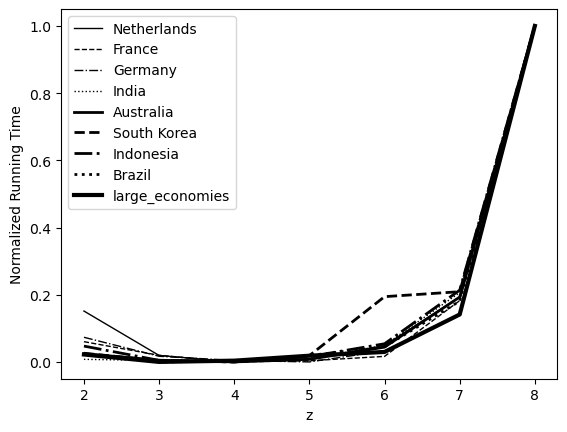

In [211]:
import matplotlib.pyplot as plt
import ast
from sklearn import preprocessing

# Assuming you have a DataFrame named 'results'
# Replace 'results' with the actual name of your DataFrame

# Function to normalize a column using min-max normalization
def normalize_column(column):
    min_max_scaler = preprocessing.MinMaxScaler()
    column_normalized = min_max_scaler.fit_transform(column.values.reshape(-1, 1))
    return column_normalized.flatten()

# Apply min-max normalization to 'running_time' column per 'country_selection'
res_le_z['running_time_normalized'] = res_le_z.groupby('country_selection')['running_time'].transform(normalize_column)

fig, ax = plt.subplots()

# Define line styles for different countries
line_styles = ['-', '--', '-.', ':']
line_widths = [1, 1, 1, 1, 2, 2, 2, 2, 3]


# Iterate over unique values in 'country_selection' column
for i, country in enumerate(res_le_z['country_selection'].unique()):
    # Filter the DataFrame for the current country
    country_df = res_le_z[res_le_z['country_selection'] == country]
    
    # Plot the normalized data for the current country with a different line style
    ax.plot(country_df['z'], country_df['running_time_normalized'], label=country , color='black', linewidth=line_widths[i % len(line_widths)],  linestyle=line_styles[i % len(line_styles)])

# Add labels and title to the plot
ax.set_xlabel('z')
ax.set_ylabel('Normalized Running Time')
#ax.set_title('Normalized Running Time vs. z for different country selections')

# Add a legend to differentiate between country selections
ax.legend()

# Save the figure as SVG
plt.savefig('runningtimeVSzscore_groter.svg', format='svg')

# Show the plot
plt.show()


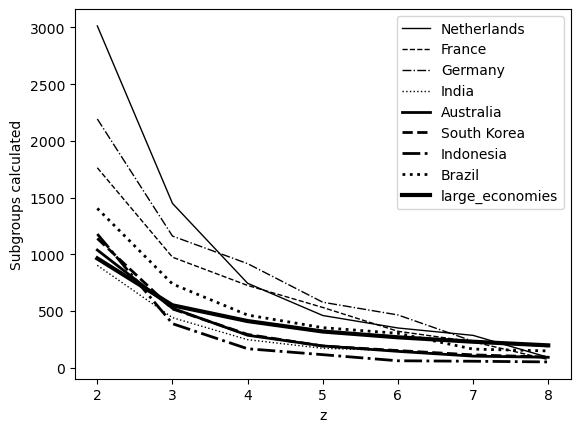

In [210]:
import matplotlib.pyplot as plt
import ast
from sklearn import preprocessing

# Assuming you have a DataFrame named 'results'
# Replace 'results' with the actual name of your DataFrame

# Function to normalize a column using min-max normalization
def normalize_column(column):
    min_max_scaler = preprocessing.MinMaxScaler()
    column_normalized = min_max_scaler.fit_transform(column.values.reshape(-1, 1))
    return column_normalized.flatten()

# Apply min-max normalization to 'running_time' column per 'country_selection'

#results['quality_measure_counter_normalized'] = results.groupby('country_selection')['quality_measure_counter'].transform(normalize_column)

fig, ax = plt.subplots()

# Define line styles for different countries
line_styles = ['-', '--', '-.', ':']
line_widths = [1, 1, 1, 1, 2, 2, 2, 2, 3]


# Iterate over unique values in 'country_selection' column
for i, country in enumerate(res_le_z['country_selection'].unique()):
    # Filter the DataFrame for the current country
    country_df = res_le_z[res_le_z['country_selection'] == country]
    
    # Plot the normalized data for the current country with a different line style
    ax.plot(country_df['z'], country_df['quality_measure_counter'], label=country , color='black', linewidth=line_widths[i % len(line_widths)],  linestyle=line_styles[i % len(line_styles)])

# Add labels and title to the plot
ax.set_xlabel('z')
ax.set_ylabel('Subgroups calculated')
#ax.set_title('Average Quality Measure vs. z for different country selections')

# Add a legend to differentiate between country selections
ax.legend()

# Save the figure as SVG
plt.savefig('nrqualVSzscore_groter.svg', format='svg')

# Show the plot
plt.show()


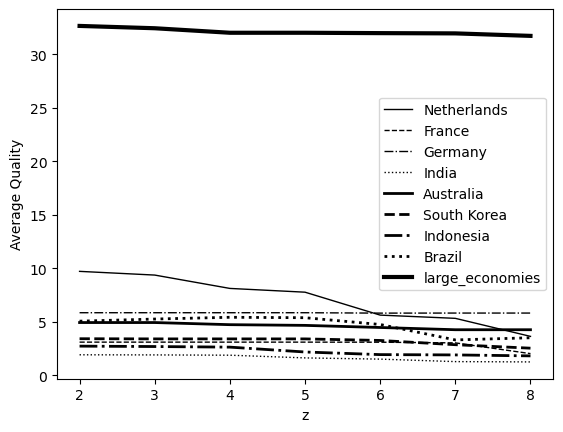

In [208]:
import matplotlib.pyplot as plt
import ast
from sklearn import preprocessing

# Assuming you have a DataFrame named 'results'
# Replace 'results' with the actual name of your DataFrame

# Function to normalize a column using min-max normalization
def normalize_column(column):
    min_max_scaler = preprocessing.MinMaxScaler()
    column_normalized = min_max_scaler.fit_transform(column.values.reshape(-1, 1))
    return column_normalized.flatten()

# Apply min-max normalization to 'running_time' column per 'country_selection'

#results['quality_measure_counter_normalized'] = results.groupby('country_selection')['quality_measure_counter'].transform(normalize_column)

fig, ax = plt.subplots()

# Define line styles for different countries
line_styles = ['-', '--', '-.', ':']
line_widths = [1, 1, 1, 1, 2, 2, 2, 2, 3]

# Iterate over unique values in 'country_selection' column
for i, country in enumerate(res_le_z['country_selection'].unique()):
    # Filter the DataFrame for the current country
    country_df = res_le_z[res_le_z['country_selection'] == country]
    
    # Plot the normalized data for the current country with a different line style
    ax.plot(country_df['z'], country_df['avg_quality'], label=country , color='black',  linestyle=line_styles[i % len(line_styles)], linewidth=line_widths[i % len(line_widths)])

# Add labels and title to the plot
ax.set_xlabel('z')
ax.set_ylabel('Average Quality')
#ax.set_title('Average Quality Measure vs. z for different country selections')

# Add a legend to differentiate between country selections
ax.legend()

# Save the figure as SVG
plt.savefig('avgqualVSzscore_groter.svg', format='svg')

# Show the plot
plt.show()


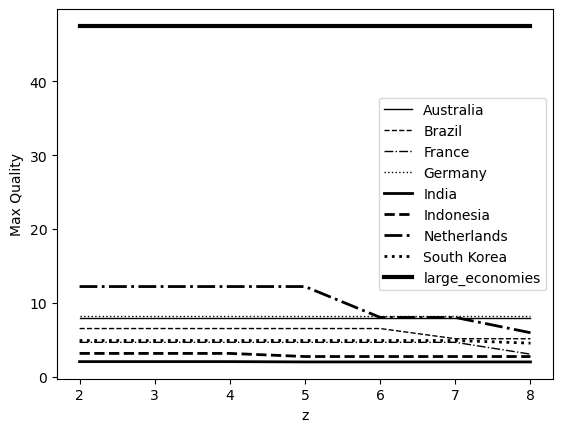

In [11]:


fig, ax = plt.subplots()

# Define line styles for different countries
line_styles = ['-', '--', '-.', ':']
line_widths = [1, 1, 1, 1, 2, 2, 2, 2, 3]

# Iterate over unique values in 'country_selection' column
for i, country in enumerate(res_le_z['country_selection'].unique()):
    # Filter the DataFrame for the current country
    country_df = res_le_z[res_le_z['country_selection'] == country]
    
    # Plot the normalized data for the current country with a different line style
    ax.plot(country_df['z'], country_df['max_qual'], label=country , color='black',  linestyle=line_styles[i % len(line_styles)], linewidth=line_widths[i % len(line_widths)])

# Add labels and title to the plot
ax.set_xlabel('z')
ax.set_ylabel('Max Quality')
#ax.set_title('Average Quality Measure vs. z for different country selections')

# Add a legend to differentiate between country selections
ax.legend()

# Save the figure as SVG
plt.savefig('maxVSzscore_groter.svg', format='svg')

# Show the plot
plt.show()


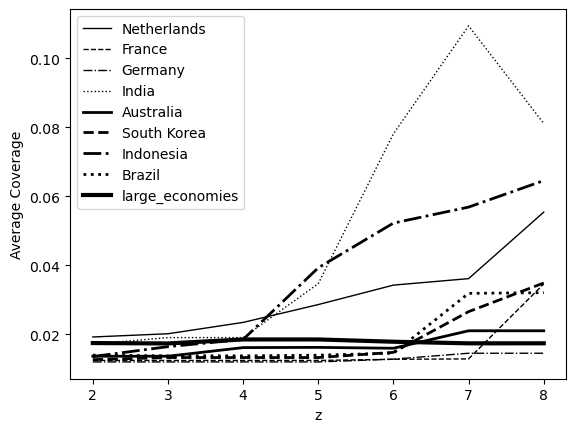

In [209]:
import matplotlib.pyplot as plt
import ast
from sklearn import preprocessing

# Assuming you have a DataFrame named 'results'
# Replace 'results' with the actual name of your DataFrame

# Function to normalize a column using min-max normalization
def normalize_column(column):
    min_max_scaler = preprocessing.MinMaxScaler()
    column_normalized = min_max_scaler.fit_transform(column.values.reshape(-1, 1))
    return column_normalized.flatten()

# Apply min-max normalization to 'running_time' column per 'country_selection'

#results['quality_measure_counter_normalized'] = results.groupby('country_selection')['quality_measure_counter'].transform(normalize_column)

fig, ax = plt.subplots()

# Define line styles for different countries
line_styles = ['-', '--', '-.', ':']
line_widths = [1, 1, 1, 1, 2, 2, 2, 2, 3]


# Iterate over unique values in 'country_selection' column
for i, country in enumerate(res_le_z['country_selection'].unique()):
    # Filter the DataFrame for the current country
    country_df = res_le_z[res_le_z['country_selection'] == country]
    
    # Plot the normalized data for the current country with a different line style
    ax.plot(country_df['z'], country_df['avg_covs'], label=country , color='black', linewidth=line_widths[i % len(line_widths)],  linestyle=line_styles[i % len(line_styles)])

# Add labels and title to the plot
ax.set_xlabel('z')
ax.set_ylabel('Average Coverage')
#ax.set_title('Average Quality Measure vs. z for different country selections')

# Add a legend to differentiate between country selections
ax.legend()

# Save the figure as SVG
plt.savefig('avgcovVSzscore_groter.svg', format='svg')

# Show the plot
plt.show()
